### Extract features and justify the methods used

In [84]:
import pandas as pd

df = pd.read_csv('cyberbullying_datasets/course_dataset/clean_cb.csv')
df = df.drop("Text", axis=1)
print("✅ Data successfully loaded!")
print(f"Number of rows: {len(df)}")
print("\nFirst few rows:")
print(df.head())

✅ Data successfully loaded!
Number of rows: 11100

First few rows:
   CB_Label                                         clean_text
0         0  damn someone nana beach not think ic steal qui...
1         0  kidding ! dick clark corpse mechanically opera...
2         0  read article jobros think damn cash jobro poke...
3         0    get fucking day sprinkle sunshine douchebaggery
4         0  listen elliott smith fucking hate kanye west v...


In [85]:
print(df['clean_text'].isna().sum())
df = df.dropna(subset=['clean_text'])
print(df['clean_text'].isna().sum())

31
0


### TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    # max_features=5000,
    ngram_range=(1,2),
)

X_tfidf = tfidf.fit_transform(df['clean_text'])

#### Sjekker topp unigrams og bigrams som forekommer for hver klassifikasjon

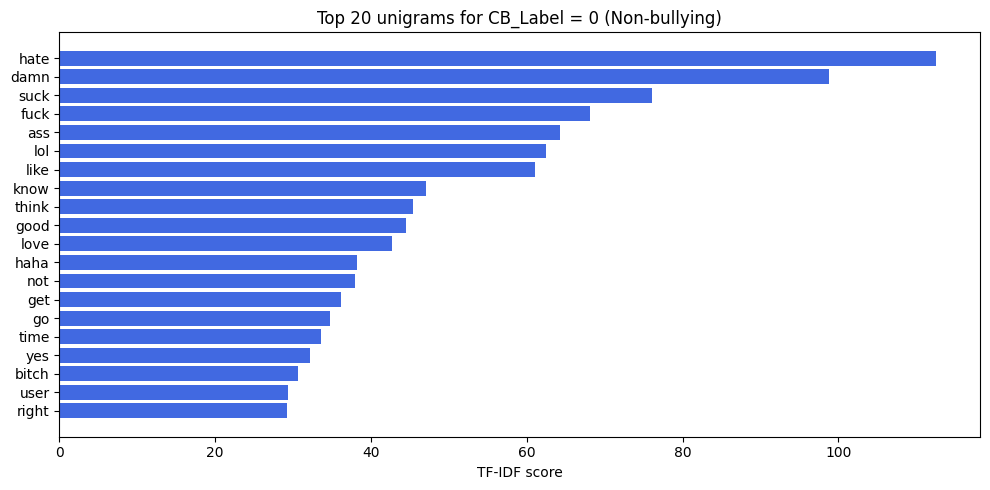

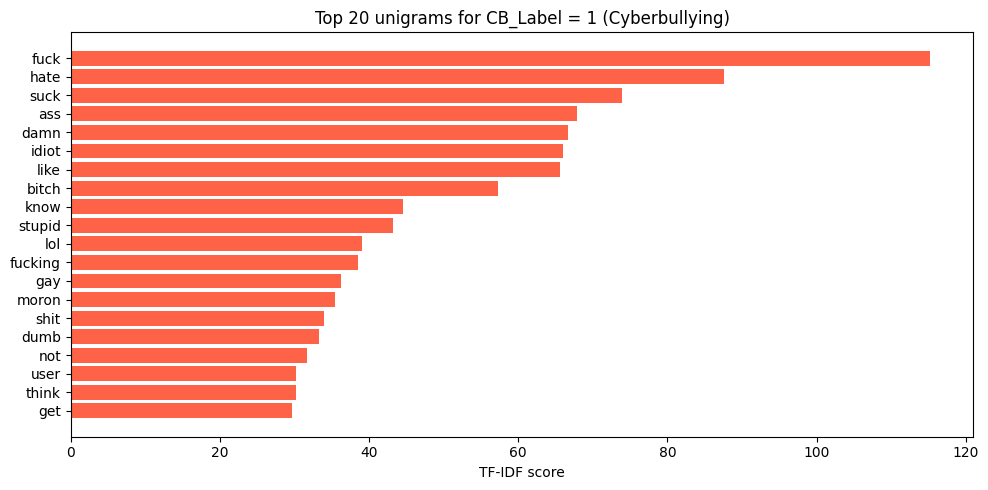

In [87]:
import numpy as np
import matplotlib.pyplot as plt
# top unigrams
for label in sorted(df['CB_Label'].unique()):
    texts = df[df['CB_Label'] == label]['clean_text']
    
    # Lær og transformer teksten i denne klassen
    X_label = tfidf.fit_transform(texts)
    
    # Hent feature names og summer TF-IDF verdier
    feature_names = tfidf.get_feature_names_out()
    tfidf_sum = np.array(X_label.sum(axis=0)).flatten()
    
    # Lag dataframe
    tfidf_df = pd.DataFrame({'term': feature_names, 'tfidf': tfidf_sum})
    tfidf_df = pd.concat([df[['CB_Label']].reset_index(drop=True), tfidf_df], axis=1)
    top20 = tfidf_df.sort_values(by='tfidf', ascending=False).head(20)
    
    # --- Plot topp 20 unigrams ---
    plt.figure(figsize=(10,5))
    plt.barh(top20['term'][::-1], top20['tfidf'][::-1], color='royalblue' if label==0 else 'tomato')
    plt.title(f'Top 20 unigrams for CB_Label = {label} ({ "Non-bullying" if label==0 else "Cyberbullying" })')
    plt.xlabel('TF-IDF score')
    plt.tight_layout()
    plt.show()

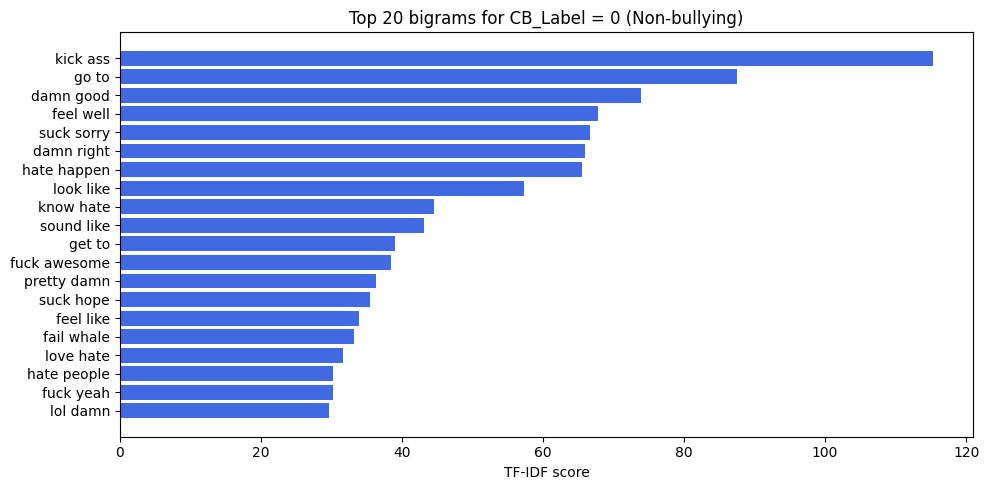

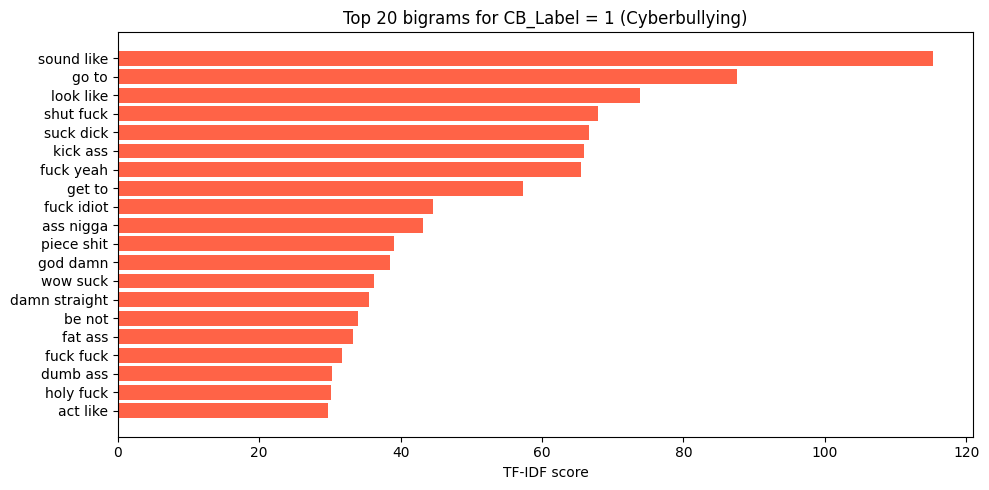

In [88]:
# Top bigrams
for label in sorted(df['CB_Label'].unique()):
    texts = df[df['CB_Label'] == label]['clean_text']
    
    # Lær og transformer teksten i denne klassen
    X_label = tfidf.fit_transform(texts)
    
    # Hent feature names og summer TF-IDF verdier
    feature_names = tfidf.get_feature_names_out()
    tfidf_sum = np.array(X_label.sum(axis=0)).flatten()
    
    # Lag dataframe
    tfidf_df = pd.DataFrame({'term': feature_names, 'tfidf': tfidf_sum})
    tfidf_df = pd.concat([df[['CB_Label']].reset_index(drop=True), tfidf_df], axis=1)

    #Topp 20 bigrams
    bigrams_df = tfidf_df[tfidf_df['term'].str.contains(' ')]
    top20_bigrams = bigrams_df.sort_values(by='tfidf', ascending=False).head(20)

    
    plt.figure(figsize=(10,5))
    plt.barh(top20_bigrams['term'][::-1], top20['tfidf'][::-1], color='royalblue' if label==0 else 'tomato')
    plt.title(f'Top 20 bigrams for CB_Label = {label} ({ "Non-bullying" if label==0 else "Cyberbullying" })')
    plt.xlabel('TF-IDF score')
    plt.tight_layout()
    plt.show()

##### Legger det i en CSV fil slik at vi kan jobbe med det!

Kjør først for enkeltord, og deretter bytt om (1,1) med (2,2) for bigrams!

In [ ]:
# --- TF-IDF vectorization ---
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,1),
    # ngram_range=(2,2),
)

# Tren TF-IDF på alle tekstene
X_tfidf = tfidf.fit_transform(df['clean_text'])

# Hent feature (ord/bigrams)
feature_names = tfidf.get_feature_names_out()

# Konverter til DataFrame
X_tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)

# Legg til labels først
X_tfidf_df.insert(0, 'CB_Label', df['CB_Label'].values)

# Sjekk resultatet
print(X_tfidf_df.shape)
print(X_tfidf_df.head())


(11069, 5001)
   CB_Label  abomination justifiable  absolute idiot  accept responsibility  \
0         0                      0.0             0.0                    0.0   
1         0                      0.0             0.0                    0.0   
2         0                      0.0             0.0                    0.0   
3         0                      0.0             0.0                    0.0   
4         0                      0.0             0.0                    0.0   

   account doc  act like  actually bitch  actually care  actually find  \
0          0.0       0.0             0.0            0.0            0.0   
1          0.0       0.0             0.0            0.0            0.0   
2          0.0       0.0             0.0            0.0            0.0   
3          0.0       0.0             0.0            0.0            0.0   
4          0.0       0.0             0.0            0.0            0.0   

   actually get  ...  young love  young man  youtube bitch  youtub

In [ ]:
# --- Lagre til CSV ---
X_tfidf_df.to_csv('TFIDF_Features_unigrams.csv', index=False)
# X_tfidf_df.to_csv('TFIDF_Features_bigrams.csv', index=False)

TF-IDF DataFrame saved as 'TFIDF_Features.csv'


In [ ]:
X_tfidf_df[['CB_Label', 'hate', 'love', 'damn', 'fuck']].head()

,CB_Label,hate,love,damn,fuck
0,0,0.000000,0.0,0.144799,0.0
1,0,0.000000,0.0,0.000000,0.0
2,0,0.000000,0.0,0.160828,0.0
3,0,0.000000,0.0,0.000000,0.0
4,0,0.134797,0.0,0.000000,0.0
